<a href="https://colab.research.google.com/github/tejasafk/E-commerce-data-analysis/blob/main/OrderHIstory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv("/content/Orders.csv")
df = pd.read_csv("/content/Details.csv")
df

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-25681,1096,658,7,Electronics,Electronic Games,COD
1,B-26055,5729,64,14,Furniture,Chairs,EMI
2,B-25955,2927,146,8,Furniture,Bookcases,EMI
3,B-26093,2847,712,8,Electronics,Printers,Credit Card
4,B-25602,2617,1151,4,Electronics,Phones,Credit Card
...,...,...,...,...,...,...,...
1495,B-25700,7,-3,2,Clothing,Hankerchief,COD
1496,B-25757,3151,-35,7,Clothing,Trousers,EMI
1497,B-25973,4141,1698,13,Electronics,Printers,COD
1498,B-25698,7,-2,1,Clothing,Hankerchief,COD


In [32]:
df.shape

(1500, 7)

In [33]:
df.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-25681,1096,658,7,Electronics,Electronic Games,COD
1,B-26055,5729,64,14,Furniture,Chairs,EMI
2,B-25955,2927,146,8,Furniture,Bookcases,EMI
3,B-26093,2847,712,8,Electronics,Printers,Credit Card
4,B-25602,2617,1151,4,Electronics,Phones,Credit Card


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1500 non-null   object
 1   Amount        1500 non-null   int64 
 2   Profit        1500 non-null   int64 
 3   Quantity      1500 non-null   int64 
 4   Category      1500 non-null   object
 5   Sub-Category  1500 non-null   object
 6   PaymentMode   1500 non-null   object
dtypes: int64(3), object(4)
memory usage: 82.2+ KB


In [35]:
df.describe(include='all')

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
count,1500,1500.000000,1500.00000,1500.000000,1500,1500,1500
unique,500,NaN,NaN,NaN,3,17,5
top,B-25656,NaN,NaN,NaN,Clothing,Saree,COD
freq,12,NaN,NaN,NaN,949,211,684
mean,NaN,291.847333,24.64200,3.743333,NaN,NaN,NaN
std,NaN,461.924620,168.55881,2.184942,NaN,NaN,NaN
min,NaN,4.000000,-1981.00000,1.000000,NaN,NaN,NaN
25%,NaN,47.750000,-12.00000,2.000000,NaN,NaN,NaN
50%,NaN,122.000000,8.00000,3.000000,NaN,NaN,NaN
75%,NaN,326.250000,38.00000,5.000000,NaN,NaN,NaN


In [36]:
df.isnull().sum()

,0
Order ID,0
Amount,0
Profit,0
Quantity,0
Category,0
Sub-Category,0
PaymentMode,0


In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df.dtypes

,0
Order ID,object
Amount,int64
Profit,int64
Quantity,int64
Category,object
Sub-Category,object
PaymentMode,object


In [39]:
df.drop_duplicates(inplace=True)

/tmp/ipykernel_3574/145659683.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Amount', y='PaymentMode', data=PaymentMode_revenue, palette='viridis')


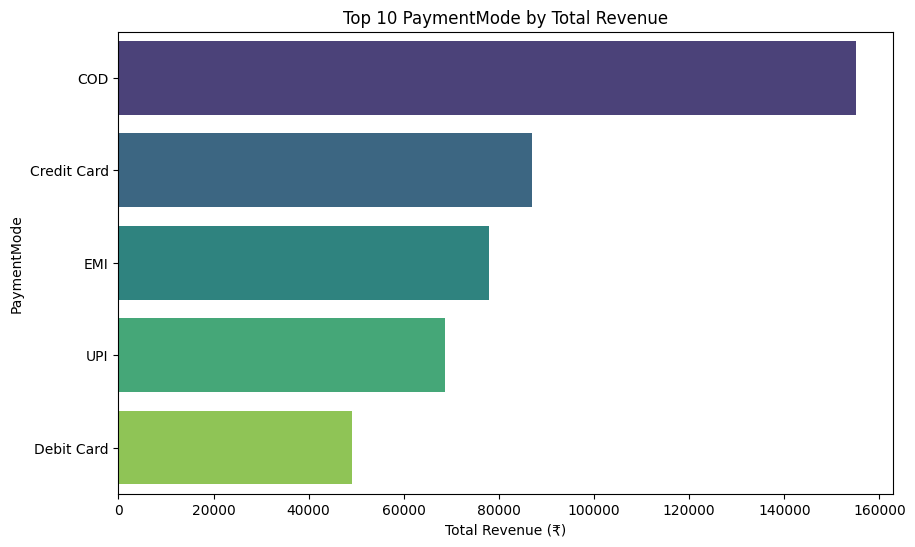

In [46]:
# Grouping by PaymentMode to find highest revenue locations
PaymentMode_revenue = df.groupby('PaymentMode')['Amount'].sum().reset_index().sort_values(by='Amount', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Amount', y='PaymentMode', data=PaymentMode_revenue, palette='viridis')
plt.title('Top 10 PaymentMode by Total Revenue')
plt.xlabel('Total Revenue (₹)')
plt.ylabel('PaymentMode')
plt.show()

In [47]:
df.to_csv("OrdersResult.csv",index=False)